# Further exercises in Python

Now you've become familiar with the basics of Python, it's time to put this knowledge to the test with a series of applications. These will be of differing levels of difficulty and not necessarily in sequential order so feel free to tackle them in whichever order you choose. You may find it helpful to sketch out your idea for how to proceed on a piece of paper before writing any code.

Some of these examples will require additional tools, and all of them can be made cleaner with more advanced Python techniques. You should be able to find documentation and examples with a quick Google search but feel free to ask for additional help.

## Dot product of two vectors

In mathematics a Euclidean vector is an element with both magnitude and direction. Typically, vectors are represented as a sequence of numbers corresponding to positions along each of the chosen coordinate axes. For example, the vector $(1,2,3)$ denotes a point at position 1 on the $x$-axis, 2 on the $y$-axis and 3 on the $z$-axis. The dot product of two vectors $\textbf{a}$ and $\textbf{b}$ is defined as $$\textbf{a} \cdot \textbf{b} = a_1b_1 + a_2b_2+a_3b_3$$ where $a_1$ denotes the first element of $\textbf{a}$. Write a function that calculates the dot product of two vectors of arbitrary length, which may be represented as lists or tuples. Test your function using the examples provided and make sure your function handles any errors correctly.

In [1]:
a = [1,2,3]  # a.b=32=b.a
b = [4,5,6]  # You can't dot vectors of different lengths so a.c, a.d, b.c, b.d are undefined.
c = [2,4,6,8] # c.d=100=d.c
d = [1,3,5,7]

def vector_dot_product(a,b):
    """ Calculate the dot product of two vectors. """
    if len(a) != len(b):  # Check for the same length.
        print("You can't take the dot product of vectors of different length.")
        return None
    
    ## No need for an else, the earlier return will exit the function.
    total = 0
    for i,j in zip(a,b):  # zip pairs the corresponding elements of two iterables.
        total += i*j
    return total

print(vector_dot_product(a,b))
print(vector_dot_product(c,d))
vector_dot_product(a,c)

32
100
You can't take the dot product of vectors of different length.


## Tournament rounds

You're in charge of a gaming tournament and need to pair the players over a series of rounds. The [Swiss pairing system](https://en.wikipedia.org/wiki/Swiss-system_tournament) is widely used to prefer matching players of similar skill levels. In each round the following rules must be followed:
* The first round is paired at random.
* Each pairing must not have played before.
* Each player must be matched with the closest rated player.
* In cases where there is a conflict between the rules, the matching prefers new players.

Write a script to generate pairings for each round of the tournament. You are given a dictionary of players and ratings to work with, and a suggested means of recording previous matchings. Generate three rounds, updating the player ratings to random values between rounds.

In [2]:
import random

player_ratings = {'Alice':50,'Bob':750,'Charlie':100,'David':10,'Emily':99,'Francis':120,'Geoff':150,'Helen':200}
player_matches = {'Alice':[],'Bob':[],'Charlie':[],'David':[],'Emily':[],'Francis':[],'Geoff':[],'Helen':[]}

def random_ratings(players, max_val):
    """ Generate a random rating for each player between 0 and the specified maximum. """
    for player in players:
        players[player] = random.randint(0,max_val)
    return players

def get_ranked_pair(sorted_players,prev_matches,first_player):
    """ Extract a single pairing for the given first player, respecting new matches. """
    # This matches the closest new player, prioritising playing up skill.
    # Check first_player is in an acceptable range.
    if first_player >= len(sorted_players):
        first_player %= len(sorted_players)
    
    # Match right.
    for i in range(first_player+1,len(sorted_players)):
        if sorted_players[i] not in prev_matches[sorted_players[first_player]]:  # If new match.
            return [sorted_players[first_player], sorted_players[i]]
    # Else match left.
    for i in range(first_player-1,-1,-1):
        try:
            if sorted_players[i] not in prev_matches[sorted_players[first_player]]:
                return [sorted_players[first_player], sorted_players[i]]
        except IndexError:
            print(i,sorted_players)
    # Else no possible match for first player, return None (not strictly necessary).
    return None

def generate_pairings(players,prev_matches,round1=False):
    """ Generates the Swiss pairings of a group of ranked players. """
    # Randomly allocate for round1.
    if round1:
        p = [k for k in players]
        random.shuffle(p)  # This is in place. 
        pairs = [p[2*i:2*i+2] for i in range(int(len(players)/2))]  # Extract a list of adjacent pairs.
            
    # Otherwise apply the pairing algorithm.
    else:
        p = sorted(players.keys(), key = lambda x:players[x])
        
        # Pair each player with the first unplayed opponent. Start with i, incremement if not valid.
        pairs = []
        starting_player = 0
        unmatched = p.copy()
        while len(pairs) < len(players)/2:
            pair = get_ranked_pair(unmatched, prev_matches, starting_player)
            if pair:  # If a pair has been found.
                pairs.append(pair)
                unmatched.remove(pair[0])
                unmatched.remove(pair[1])
            else:  # No possible pair exists.
                pairs = []
                unmatched = p.copy()
                starting_player += 1                
        
    # Add the pairings to the matches lists.
    for home, away in pairs:  # Extracts the two elements in one line.
        prev_matches[home].append(away)
        prev_matches[away].append(home)  
    
    return pairs, prev_matches
        

pairings1, player_matches = generate_pairings(player_ratings,player_matches,round1=True)
print('Round 1:')
print(pairings1)

player_ratings = random_ratings(player_ratings,1000)
pairings2, player_matches = generate_pairings(player_ratings,player_matches)
print('Round 2:')
print(pairings2)

player_ratings = random_ratings(player_ratings,1000)
pairings3, player_matches = generate_pairings(player_ratings,player_matches)
print('Round 3:')
print(pairings3)

Round 1:
[['Charlie', 'Helen'], ['David', 'Emily'], ['Alice', 'Francis'], ['Bob', 'Geoff']]
Round 2:
[['Emily', 'Helen'], ['Charlie', 'Bob'], ['Francis', 'David'], ['Alice', 'Geoff']]
Round 3:
[['Emily', 'Alice'], ['Helen', 'Francis'], ['Charlie', 'Geoff'], ['David', 'Bob']]


## Fibonacci numbers

Write a function that computes the list of the $n^{th}$ Fibonacci number. The first two Fibonacci numbers are 1 and 1. The $n+1^{th}$ Fibonacci number can be computed by adding the $n^{th}$ and the $n-1^{th}$ Fibonacci number. The first few are therefore 1, 1, 1+1=2, 1+2=3, 2+3=5, 3+5=8.

Print the Fibonacci numbers between $n$=100 and $n$=110.

In [3]:
def fibonacci(min_n, max_n):
    """ Calculates the first max_n Fibonacci numbers, and returns the Fibonacci numbers between n=min_n and n=max_n """
    fibs = [0]*max_n  # List to store the values.
    fibs[0] = 1
    fibs[1] = 1
    print(len(fibs))
    for i in range(2,len(fibs)):
        fibs[i] = fibs[i-1] + fibs[i-2]
    
    return fibs[min_n-1:]

print(fibonacci(100,110))    

110
[354224848179261915075, 573147844013817084101, 927372692193078999176, 1500520536206896083277, 2427893228399975082453, 3928413764606871165730, 6356306993006846248183, 10284720757613717413913, 16641027750620563662096, 26925748508234281076009, 43566776258854844738105]


## Morse code

Write a function that automatically converts English text to Morse code. You can find a [dictionary of Morse code characters on Wikipedia](https://en.wikipedia.org/wiki/Morse_code), and a copy is included for convenience. Ignore any capitalisation and punctuation in your English input. Letters in Morse code should be separated by a single space, and words by tabs.

Test your function on several sentences.

Bonus: Can you make Python play the Morse code translation through the speakers?

In [5]:
eng_morse_dict = { 'A':'.-', 'B':'-...', 
                    'C':'-.-.', 'D':'-..', 'E':'.', 
                    'F':'..-.', 'G':'--.', 'H':'....', 
                    'I':'..', 'J':'.---', 'K':'-.-', 
                    'L':'.-..', 'M':'--', 'N':'-.', 
                    'O':'---', 'P':'.--.', 'Q':'--.-', 
                    'R':'.-.', 'S':'...', 'T':'-', 
                    'U':'..-', 'V':'...-', 'W':'.--', 
                    'X':'-..-', 'Y':'-.--', 'Z':'--..', 
                    '1':'.----', '2':'..---', '3':'...--', 
                    '4':'....-', '5':'.....', '6':'-....', 
                    '7':'--...', '8':'---..', '9':'----.', 
                    '0':'-----',' ':'\t', '':' '}  # Added padding maps for spacing words and letters.

def eng_to_morse(text,dictionary=eng_morse_dict):
    """ Translates a given string from English into Morse code. """
    
    # Conver to upper case text.
    text = text.upper()
    
    output = ''
    for letter in text:
        output += dictionary[letter]
        if letter != ' ':
            output += ' '
    return output
    
print(eng_to_morse('Hello world'))

import winsound
import time

def play_morse(text):
    """ Play a given Morse code statement through the speakers. """
    for letter in text:
        if letter == '.':
            winsound.Beep(2500,250)  # Beep takes frequency, duration arguments.
        elif letter == '-':
            winsound.Beep(2500,750)
        elif letter == ' ':
            time.sleep(0.75)  # Wait 3/4 sec.
        elif letter == '\t':
            time.sleep(1)  # Wait 1 sec. between words.

play_morse(eng_to_morse('Hello world'))

.... . .-.. .-.. --- 	.-- --- .-. .-.. -.. 


## Writing styles in A Tale of Two Cities

We're now going to return to A Tale of Two Cities by Charles Dickens and analyse different patterns in the text. Before you start working with the file, you will find it useful to open it in a text viewer (e.g. Notepad++) to see how it is structured.

1) Create a list of all the sentences in the book. How many sentences are there? Hint: some sentences span multiple lines.

2) From the list of all sentences, create a list of all sentences of speech. What proportion of the sentences in the book are speech?

3) The book is divided into a series of chapters. Look through the file to determine how the chapter breaks are represented. Use your answers to parts 1) and 2) to plot the proportion of sentences that are speech in each chapter.

1) There are 6599 sentences in A Tale of Two Cities.
2) There are 2663 speech sentences in A Tale of Two Cities. 40.35 percent of all sentences are speech.


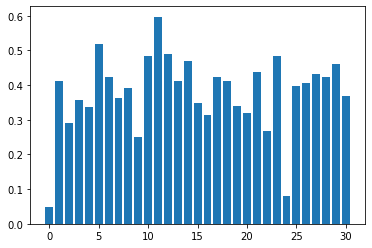

In [6]:
import matplotlib.pyplot as plt

text = ""  # Add all text in the file to a single string.

with open('tale-of-two-cities.txt','r') as f:
    for line in f:
        text += line.strip() + " " # strip() removes leading and trailing whitespace like new line characters. In this case
        # it works because there are no spaces between words at the end of lines. We manually add these spaces in.

sentences = text.split('.')
print('1) There are %d sentences in A Tale of Two Cities.' % len(sentences))
# Note this is a simplification. It will split incorrectly in cases like "Hello Mr. Lorry".

speech = [s for s in sentences if '"' in s]  # This makes a list of all sentences containing a speech mark.
print("2) There are %d speech sentences in A Tale of Two Cities. %.2f percent of all sentences are speech." % (len(speech),100*len(speech)/len(sentences)))

# Chapters split on Roman numerals e.g. "V. The Wine-shop". We are considering all three books together, the highest chapter
# number I found was 24.
chapter_labels = ['I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI','XVII','XVIII','XIX','XX','XXI','XXII','XXIII','XXIV']
chapters = []
chapter = []
for s in sentences:
    if s.strip() in chapter_labels:  # Chapter headings have leading whitespace.
        chapters.append(chapter)  # Store and reset the chapter.
        chapter = []  # Note we aren't storing the sentence with the chapter numerals.
    else:
        chapter.append(s)
chapters.append(chapter)  # Need to store the last chapter.

chapters_speech = [[s for s in sents if '"' in s] for sents in chapters]  # Double list comprehension for space efficiency.

chapt_speech_prop = [0]*len(chapters)
for i in range(len(chapters)):
    chapt_speech_prop[i] = len(chapters_speech[i])/len(chapters[i])
    
plt.bar(range(len(chapters)),chapt_speech_prop)
plt.show()

## Password generator

Write a function to generate random passwords. Some conditions that passwords may require include:
* At least one capital letter.
* At least one number.
* At least one special character (you should define these yourself).

Users should be able to specify the length of the password and which of these conditions it must satisfy. You are given the alphabet and numbers to get you started.

Test your function by generating passwords of length 10 that satisfy each condition in turn.

In [7]:
import string
lowers = list(string.ascii_lowercase)
uppers = list(string.ascii_uppercase)
nums = list(map(str,range(10)))  # Look up what the map function does.

spec = [',','.','/',']','[','{','@','!','£','$','%','^','&','(',')']  # This is not exhaustive but suffices for this example.

import numpy # There is a function here used to sample from lists.
import random # This has a function to shuffle a list.

def gen_password(length,use_uppers=0,use_numbers=0,use_specials=0):
    """ Generate a random password of specified length using the required conditions. """
    # Here the arguments allow users to specify the number of times they want to meet each condition. Note that providing
    # a value when defining a function designates it as the default and you do not need to provide this argument if you
    # wish to use the default value.
    
    if use_uppers + use_numbers + use_specials > length or length <= 0:  # Catch some errors before they occur.
        return None  # Returning a None type is one way to raise an error but you could use exceptions here.
    
    password = []
    password += list(numpy.random.choice(uppers,use_uppers))  # Draw the random characters for the password.
    password += list(numpy.random.choice(nums,use_numbers))
    password += list(numpy.random.choice(spec,use_specials))
    password += list(numpy.random.choice(lowers,length-use_uppers-use_numbers-use_specials))
    
    random.shuffle(password)  # Randomly arrange the chosen letters.
    
    return ''.join(password)  # Look up what join does.

print(gen_password(10))
print(gen_password(10,use_uppers=2))
print(gen_password(10,use_numbers=3))
print(gen_password(10,use_specials=4))
print(gen_password(3,use_uppers=2,use_numbers=2))

bigdpxiyjs
gobvkaMlEr
5kq7ywc4cf
bqc%@y()iu
None
